# 04 — Analyse des résultats (offline)

Charge les JSON déjà produits (`eval/results/`) et visualise sans rappeler l'API.

Utile pour rédiger le rapport ou rejouer les graphiques rapidement.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "eval" / "results"
print("Fichiers disponibles :")
for p in sorted(RESULTS.glob("*.json")):
    print("-", p.name)

Fichiers disponibles :
- llm_eval_latest.json
- performance_study_latest.json
- retrieval_eval_latest.json


In [2]:
perf_path = RESULTS / "performance_study_latest.json"
if not perf_path.exists():
    raise FileNotFoundError(
        "Lancer d'abord : python scripts/run_performance_study.py"
    )

report = json.loads(perf_path.read_text(encoding="utf-8"))
print("timestamp =", report["timestamp"])
print("best_retrieval_mode =", report["best_retrieval_mode"])
print("best_advanced_config =", report.get("best_advanced_config"))
print()
for c in report.get("conclusions", []):
    print("-", c)

timestamp = 2026-08-10T12:05:01Z
best_retrieval_mode = vector
best_advanced_config = hybrid (baseline)

- Le mode `vector` offre le meilleur couple Hit Rate / MRR (100.0% / 0.917).
- Rewrite + rerank n'améliorent pas le Hit Rate ici (-5.0%) ; utile surtout pour le ranking (MRR) ou la qualité perçue des réponses.
- La config recommandée en production reste celle du meilleur score qualité/latence observé (voir tableaux).


In [3]:
df_modes = pd.DataFrame([
    {
        "mode": r["mode"],
        "hit_rate": r["metrics"]["hit_rate"],
        "mrr": r["metrics"]["mrr"],
        "mean_ms": r["latency"]["mean_ms"],
        "p95_ms": r["latency"]["p95_ms"],
    }
    for r in report["retrieval_modes"]
])

df_abl = pd.DataFrame([
    {
        "config": r["config"],
        "hit_rate": r["metrics"]["hit_rate"],
        "mrr": r["metrics"]["mrr"],
        "mean_ms": r["latency"]["mean_ms"],
    }
    for r in report.get("ablations", [])
])

df_e2e = pd.DataFrame([
    {
        "config": r["config"],
        "mean_ms": r["latency"]["mean_ms"],
        "p50_ms": r["latency"]["p50_ms"],
        "p95_ms": r["latency"]["p95_ms"],
    }
    for r in report.get("e2e_latency", [])
])

display(df_modes)
display(df_abl)
display(df_e2e)

,mode,hit_rate,mrr,mean_ms,p95_ms
0,vector,1.0,0.916667,321.8,922.8
1,bm25,1.0,0.820833,55.3,74.5
2,hybrid,1.0,0.901667,280.3,314.6


,config,hit_rate,mrr,mean_ms
0,hybrid (baseline),1.00,0.901667,285.7
1,hybrid+rewrite,0.90,0.816667,1609.2
2,hybrid+rerank,0.95,0.900000,1864.6
3,hybrid+rewrite+rerank,0.95,0.891667,3069.3


,config,mean_ms,p50_ms,p95_ms
0,e2e,6113.7,6133.5,7902.5
1,e2e+rewrite+rerank,7745.1,7087.3,9004.5


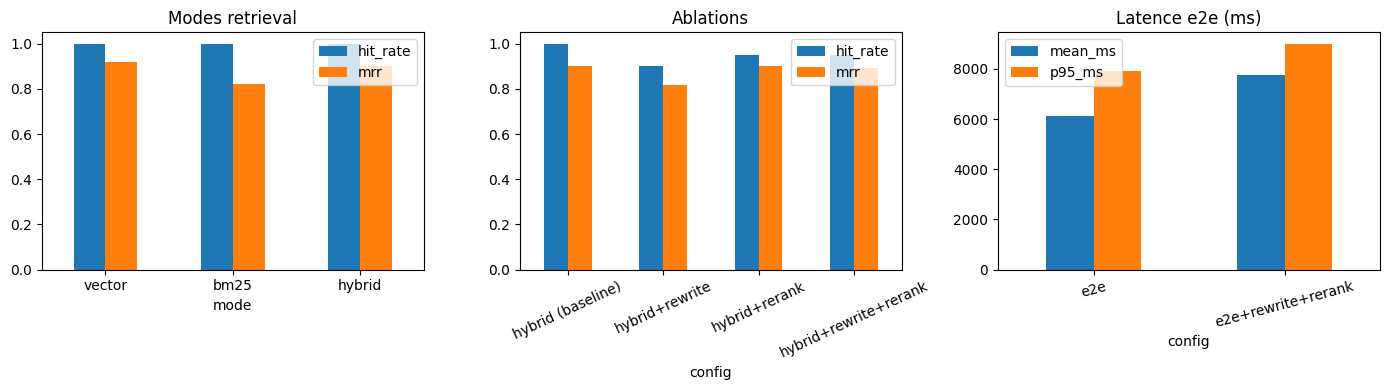

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df_modes.plot(x="mode", y=["hit_rate", "mrr"], kind="bar", ax=axes[0], rot=0)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Modes retrieval")

if not df_abl.empty:
    df_abl.plot(x="config", y=["hit_rate", "mrr"], kind="bar", ax=axes[1], rot=25)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Ablations")

if not df_e2e.empty:
    df_e2e.plot(x="config", y=["mean_ms", "p95_ms"], kind="bar", ax=axes[2], rot=15)
    axes[2].set_title("Latence e2e (ms)")

plt.tight_layout()
plt.show()

In [5]:
md = ROOT / "eval" / "ETUDE_PERFORMANCE.md"
if md.exists():
    print(md.read_text(encoding="utf-8"))
else:
    print("Pas encore de rapport Markdown.")

# Étude de performance — ArchéoGuide

*Généré le 2026-08-10T12:05:01Z (UTC).*

## Objectif

Comparer les stratégies de retrieval et les optimisations avancées (query rewriting, re-ranking) sur un jeu de questions de référence, en mesurant **qualité** (Hit Rate@k, MRR) et **latence**.

## Protocole

- Jeu de référence : `eval/ground_truth.json` (20 questions)
- `top_k` = 5
- Collection Qdrant : `chantiers_archeo`
- Embedding : `text-embedding-3-small`
- LLM : `gpt-4o-mini`
- Pertinence : un chunk est pertinent s'il contient au moins un `expected_keywords` de la question

## 1. Comparaison des modes de retrieval

| Mode | Hit Rate@k | MRR | Latence moyenne | P95 |
|---|---:|---:|---:|---:|
| `vector` | 100.0% | 0.917 | 322 ms | 923 ms |
| `bm25` | 100.0% | 0.821 | 55 ms | 74 ms |
| `hybrid` | 100.0% | 0.902 | 280 ms | 315 ms |

**Meilleur mode (qualité)** : `vector`

## 2. Ablations (rewrite / rerank) sur hybrid

Mesure la qualité des chunks transmis au LLM, sans noter la génération.

| 